# 性能分析与优化实践：XQA Attention 调优指南

本文档提供 XQA Attention 的系统性性能分析方法和优化实践，帮助你识别瓶颈、调优参数、提升性能。

## 学习目标

1. **性能分析工具**：掌握 Nsight Systems、Nsight Compute 的使用
2. **性能指标**：理解关键性能指标及其含义
3. **瓶颈识别**：识别内存、计算、同步等瓶颈
4. **参数调优**：系统性地调优 XQA 参数
5. **优化案例**：实际的优化案例和效果分析

## 前置知识

- 完成前面的 Attention 基础学习
- 理解 XQA 的架构和实现
- 熟悉基本的 CUDA 编程


## 1. 性能分析框架

### 1.1 性能分析流程

```mermaid
graph TB
    A[1. 建立基线] --> B[2. Profiling]
    B --> C[3. 瓶颈识别]
    C --> D[4. 优化实施]
    D --> E[5. 验证效果]
    E --> F{达到目标?}
    F -->|否| B
    F -->|是| G[完成]
    
    A --> A1[测量初始性能]
    A --> A2[记录配置参数]
    
    B --> B1[系统级 Profiling<br/>Nsight Systems]
    B --> B2[Kernel 级 Profiling<br/>Nsight Compute]
    
    C --> C1[内存瓶颈]
    C --> C2[计算瓶颈]
    C --> C3[同步瓶颈]
    
    D --> D1[调整参数]
    D --> D2[修改代码]
    D --> D3[改变策略]
    
    style A fill:#ff6b6b
    style C fill:#ffa07a
    style D fill:#ffb347
    style G fill:#ffd700
```

### 1.2 关键性能指标

| 指标类别 | 具体指标 | 目标值 | 说明 |
|---------|---------|--------|------|
| **吞吐量** | Tokens/sec | 最大化 | 整体处理速度 |
| **延迟** | ms/token | 最小化 | 单 token 生成时间 |
| **内存** | GB | 最小化 | 显存占用 |
| **利用率** | SM Utilization | >80% | 计算单元利用率 |
| **带宽** | Memory BW % | >70% | 内存带宽利用率 |
| **效率** | Tensor Core % | >60% | Tensor Core 利用率 |


In [2]:
import sys
sys.path.append('..')

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple
import time
import json

# 设置绘图样式
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial']
plt.rcParams['axes.unicode_minus'] = False
sns.set_palette("husl")

# 检查 CUDA 可用性
print(f"PyTorch 版本: {torch.__version__}")
print(f"CUDA 可用: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA 版本: {torch.version.cuda}")
    print(f"GPU 设备: {torch.cuda.get_device_name(0)}")
    print(f"GPU 数量: {torch.cuda.device_count()}")
    print(f"显存总量: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
else:
    print("警告: CUDA 不可用，将使用 CPU 进行演示")

PyTorch 版本: 2.10.0+cu128
CUDA 可用: True
CUDA 版本: 12.8
GPU 设备: NVIDIA GeForce RTX 5050 Laptop GPU
GPU 数量: 1
显存总量: 7.96 GB


## 2. 性能测试框架

### 2.1 基准测试设计

一个好的基准测试应该：
- **可重复**：多次运行结果一致
- **代表性**：覆盖典型使用场景
- **全面性**：测试不同配置和参数
- **准确性**：正确测量时间和资源


In [3]:
class AttentionBenchmark:
    """Attention 性能测试框架"""
    
    def __init__(self, device='cuda' if torch.cuda.is_available() else 'cpu'):
        self.device = device
        self.results = []
    
    def benchmark_attention(
        self,
        batch_size: int,
        seq_len: int,
        num_heads: int,
        head_dim: int,
        num_iterations: int = 100,
        warmup: int = 10,
        name: str = "attention"
    ) -> Dict:
        """测试 Attention 性能"""
        
        # 创建输入数据
        Q = torch.randn(batch_size, num_heads, seq_len, head_dim, 
                       device=self.device, dtype=torch.float16)
        K = torch.randn(batch_size, num_heads, seq_len, head_dim, 
                       device=self.device, dtype=torch.float16)
        V = torch.randn(batch_size, num_heads, seq_len, head_dim, 
                       device=self.device, dtype=torch.float16)
        
        # Warmup
        for _ in range(warmup):
            _ = self._attention_forward(Q, K, V)
        
        if self.device == 'cuda':
            torch.cuda.synchronize()
        
        # 测量时间
        times = []
        for _ in range(num_iterations):
            start = time.perf_counter()
            output = self._attention_forward(Q, K, V)
            if self.device == 'cuda':
                torch.cuda.synchronize()
            end = time.perf_counter()
            times.append((end - start) * 1000)  # ms
        
        # 计算统计量
        times = np.array(times)
        result = {
            'name': name,
            'batch_size': batch_size,
            'seq_len': seq_len,
            'num_heads': num_heads,
            'head_dim': head_dim,
            'mean_ms': np.mean(times),
            'std_ms': np.std(times),
            'min_ms': np.min(times),
            'max_ms': np.max(times),
            'p50_ms': np.percentile(times, 50),
            'p95_ms': np.percentile(times, 95),
            'p99_ms': np.percentile(times, 99),
        }
        
        # 计算吞吐量
        tokens_per_batch = batch_size * seq_len
        result['tokens_per_sec'] = tokens_per_batch / (result['mean_ms'] / 1000)
        
        # 计算 FLOPS
        # Attention: 2 * batch * heads * seq^2 * head_dim (QK^T + PV)
        flops = 4 * batch_size * num_heads * seq_len * seq_len * head_dim
        result['tflops'] = flops / (result['mean_ms'] / 1000) / 1e12
        
        self.results.append(result)
        return result
    
    def _attention_forward(self, Q, K, V):
        """标准 Attention 前向传播"""
        scale = 1.0 / np.sqrt(Q.shape[-1])
        scores = torch.matmul(Q, K.transpose(-2, -1)) * scale
        attn = torch.softmax(scores, dim=-1)
        output = torch.matmul(attn, V)
        return output
    
    def get_results_df(self) -> pd.DataFrame:
        """获取结果 DataFrame"""
        return pd.DataFrame(self.results)
    
    def plot_results(self, metric='mean_ms', group_by='seq_len'):
        """绘制结果"""
        df = self.get_results_df()
        
        fig, ax = plt.subplots(figsize=(10, 6))
        
        for name in df['name'].unique():
            data = df[df['name'] == name]
            ax.plot(data[group_by], data[metric], 'o-', 
                   label=name, linewidth=2, markersize=8)
        
        ax.set_xlabel(group_by, fontsize=12)
        ax.set_ylabel(metric, fontsize=12)
        ax.set_title(f'Performance Comparison: {metric}', 
                    fontsize=14, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
        
        if group_by == 'seq_len':
            ax.set_xscale('log')
        if 'ms' in metric or 'time' in metric:
            ax.set_yscale('log')
        
        plt.tight_layout()
        plt.show()

# 创建测试实例
benchmark = AttentionBenchmark()
print("性能测试框架已就绪")

性能测试框架已就绪


开始基准测试...

测试 seq_len=128... 完成 (0.24 ms)
测试 seq_len=256... 完成 (0.59 ms)
测试 seq_len=512... 完成 (2.65 ms)
测试 seq_len=1024... 完成 (10.12 ms)
测试 seq_len=2048... 完成 (36.01 ms)

基准测试完成！

性能测试结果:
 seq_len   mean_ms   std_ms  tokens_per_sec   tflops
     128  0.237822 0.091150    2.152871e+06 4.514897
     256  0.590538 0.129028    1.734012e+06 7.272974
     512  2.654200 0.203979    7.716073e+05 6.472711
    1024 10.122576 0.324365    4.046401e+05 6.788734
    2048 36.012432 1.970967    2.274770e+05 7.632862


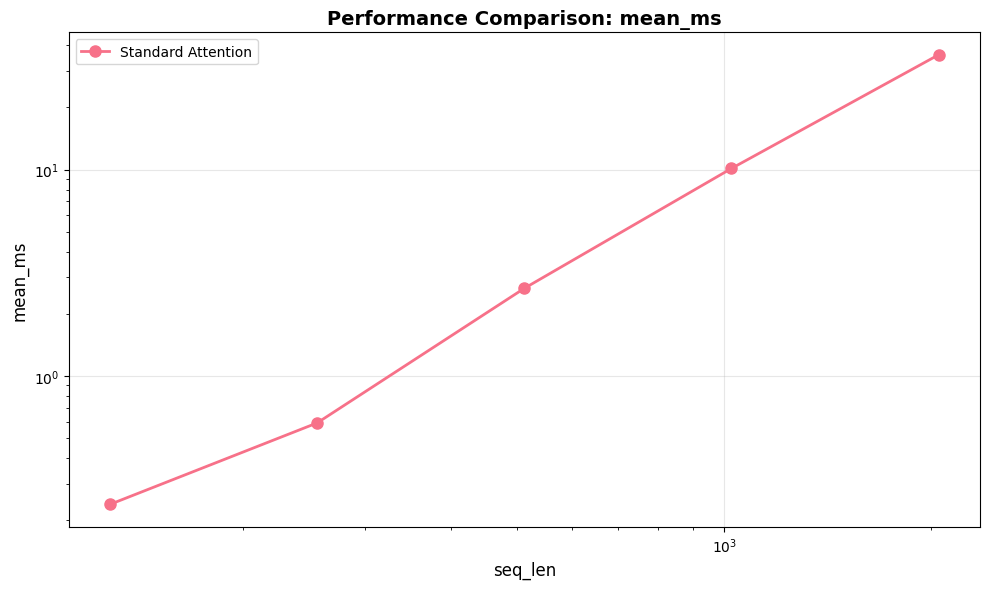

In [4]:
# 运行基准测试
print("开始基准测试...\n")

# 测试不同序列长度
seq_lens = [128, 256, 512, 1024, 2048]
batch_size = 4
num_heads = 32
head_dim = 128

for seq_len in seq_lens:
    print(f"测试 seq_len={seq_len}...", end=' ')
    result = benchmark.benchmark_attention(
        batch_size=batch_size,
        seq_len=seq_len,
        num_heads=num_heads,
        head_dim=head_dim,
        num_iterations=50,
        warmup=5,
        name=f"Standard Attention"
    )
    print(f"完成 ({result['mean_ms']:.2f} ms)")

print("\n基准测试完成！")

# 显示结果
df = benchmark.get_results_df()
print("\n性能测试结果:")
print(df[['seq_len', 'mean_ms', 'std_ms', 'tokens_per_sec', 'tflops']].to_string(index=False))

# 绘制结果
benchmark.plot_results(metric='mean_ms', group_by='seq_len')

## 3. Roofline 模型分析

Roofline 模型帮助我们理解 kernel 是内存受限还是计算受限。

### 3.1 Roofline 模型原理

```mermaid
graph TB
    A[Roofline 模型] --> B[计算强度<br/>Arithmetic Intensity]
    A --> C[性能上界]
    
    B --> B1["AI = FLOPs / Bytes"]
    B1 --> B2[低 AI: 内存受限]
    B1 --> B3[高 AI: 计算受限]
    
    C --> C1[内存带宽上界<br/>Peak BW × AI]
    C --> C2[计算吞吐量上界<br/>Peak FLOPS]
    
    style B2 fill:#ff6b6b
    style B3 fill:#ffa07a
    style C1 fill:#ffb347
    style C2 fill:#ffd700
```

### 3.2 Attention 的计算强度

对于标准 Attention：
- **FLOPs**: `4 × B × H × N² × D` (QK^T 和 PV 各 2×)
- **Memory**: `3 × B × H × N × D × sizeof(dtype)` (Q, K, V 输入)
- **AI**: `(4 × N × D) / (3 × D × sizeof) ≈ 1.33 × N / sizeof`

对于 FP16 (2 bytes):
- N=128: AI ≈ 85 FLOPs/Byte
- N=1024: AI ≈ 682 FLOPs/Byte
- N=4096: AI ≈ 2730 FLOPs/Byte

### 3.3 硬件性能上界

| GPU | Peak TFLOPS (FP16) | Peak BW (GB/s) | Ridge Point (FLOPs/Byte) |
|-----|-------------------|----------------|-------------------------|
| A100 | 312 | 1935 | 161 |
| H100 | 989 | 3350 | 295 |
| L40S | 362 | 864 | 419 |

**结论**: 
- 短序列 (N<512): 可能内存受限
- 长序列 (N>1024): 通常计算受限


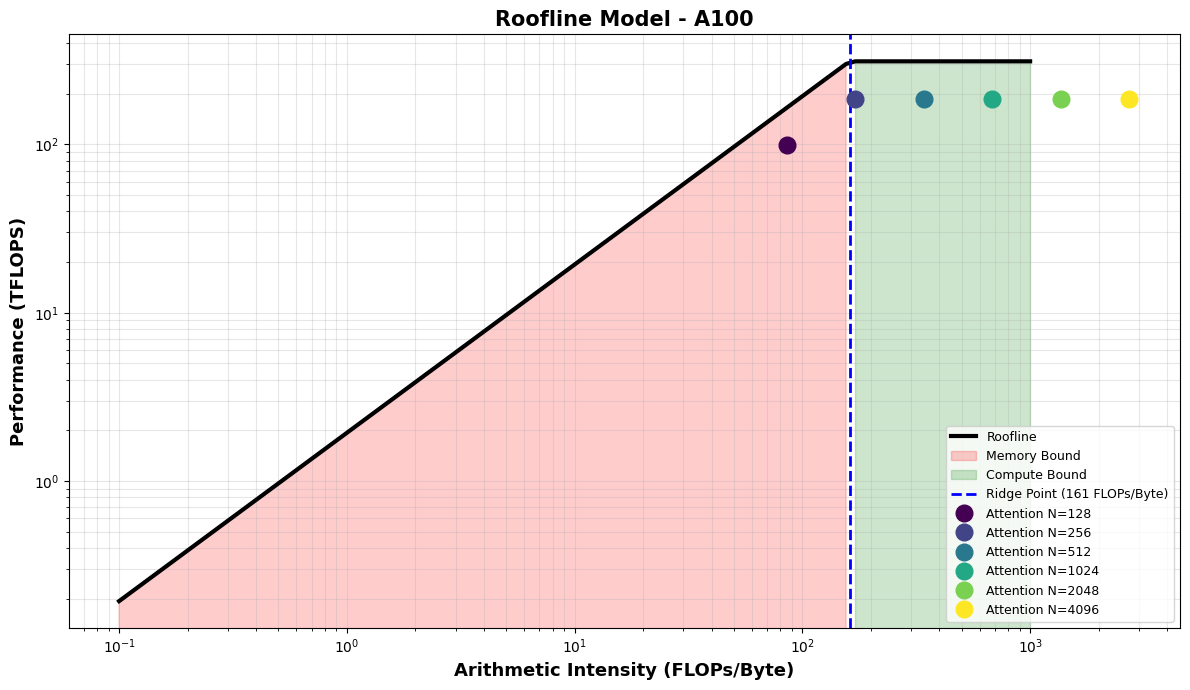


A100 规格:
  Peak TFLOPS (FP16): 312
  Peak Bandwidth: 1935 GB/s
  Ridge Point: 161 FLOPs/Byte

Attention 计算强度:
  N=128 :     85 FLOPs/Byte - Memory Bound
  N=256 :    171 FLOPs/Byte - Compute Bound
  N=512 :    341 FLOPs/Byte - Compute Bound
  N=1024:    683 FLOPs/Byte - Compute Bound
  N=2048:   1365 FLOPs/Byte - Compute Bound
  N=4096:   2731 FLOPs/Byte - Compute Bound


In [5]:
# Roofline 模型可视化
def plot_roofline(gpu_name='A100'):
    """绘制 Roofline 模型"""
    
    # GPU 规格
    specs = {
        'A100': {'peak_tflops': 312, 'peak_bw_gbs': 1935},
        'H100': {'peak_tflops': 989, 'peak_bw_gbs': 3350},
        'L40S': {'peak_tflops': 362, 'peak_bw_gbs': 864},
    }
    
    spec = specs[gpu_name]
    peak_tflops = spec['peak_tflops']
    peak_bw_gbs = spec['peak_bw_gbs']
    ridge_point = peak_tflops * 1000 / peak_bw_gbs  # FLOPs/Byte
    
    # 计算强度范围
    ai_range = np.logspace(-1, 3, 100)  # 0.1 to 1000 FLOPs/Byte
    
    # Roofline
    roofline = np.minimum(
        peak_bw_gbs * ai_range,  # 内存受限
        peak_tflops * 1000  # 计算受限
    )
    
    # Attention 的计算强度（不同序列长度）
    seq_lens = [128, 256, 512, 1024, 2048, 4096]
    head_dim = 128
    dtype_size = 2  # FP16
    
    attention_ai = []
    for N in seq_lens:
        ai = (4 * N * head_dim) / (3 * head_dim * dtype_size)
        attention_ai.append(ai)
    
    # 绘图
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Roofline
    ax.plot(ai_range, roofline / 1000, 'k-', linewidth=3, label='Roofline')
    
    # 内存受限区域
    ax.fill_between(ai_range[ai_range < ridge_point], 0, 
                     (peak_bw_gbs * ai_range[ai_range < ridge_point]) / 1000,
                     alpha=0.2, color='red', label='Memory Bound')
    
    # 计算受限区域
    ax.fill_between(ai_range[ai_range >= ridge_point], 0, peak_tflops,
                     alpha=0.2, color='green', label='Compute Bound')
    
    # Ridge point
    ax.axvline(x=ridge_point, color='blue', linestyle='--', linewidth=2,
               label=f'Ridge Point ({ridge_point:.0f} FLOPs/Byte)')
    
    # Attention 点
    colors_seq = plt.cm.viridis(np.linspace(0, 1, len(seq_lens)))
    for i, (N, ai) in enumerate(zip(seq_lens, attention_ai)):
        # 假设达到 60% 的理论性能
        achieved_tflops = min(peak_bw_gbs * ai, peak_tflops * 1000) * 0.6 / 1000
        ax.plot(ai, achieved_tflops, 'o', markersize=12, 
               color=colors_seq[i], label=f'Attention N={N}')
    
    ax.set_xlabel('Arithmetic Intensity (FLOPs/Byte)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Performance (TFLOPS)', fontsize=13, fontweight='bold')
    ax.set_title(f'Roofline Model - {gpu_name}', fontsize=15, fontweight='bold')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3, which='both')
    ax.legend(fontsize=9, loc='lower right')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n{gpu_name} 规格:")
    print(f"  Peak TFLOPS (FP16): {peak_tflops}")
    print(f"  Peak Bandwidth: {peak_bw_gbs} GB/s")
    print(f"  Ridge Point: {ridge_point:.0f} FLOPs/Byte")
    print(f"\nAttention 计算强度:")
    for N, ai in zip(seq_lens, attention_ai):
        bound = "Memory Bound" if ai < ridge_point else "Compute Bound"
        print(f"  N={N:<4}: {ai:>6.0f} FLOPs/Byte - {bound}")

# 绘制 A100 的 Roofline
plot_roofline('A100')

## 4. Profiling 工具使用指南

### 4.1 Nsight Systems - 系统级分析

Nsight Systems 用于分析整体应用性能，识别 CPU/GPU 交互、kernel 启动开销等。

```bash
# 基本使用
nsys profile -o timeline \
  --trace=cuda,nvtx,osrt \
  --cuda-memory-usage=true \
  --force-overwrite=true \
  ./your_app

# 查看结果
nsys-ui timeline.nsys-rep
```

**关键指标**:
- **GPU Utilization**: GPU 忙碌时间占比
- **Kernel Duration**: 各 kernel 执行时间
- **Memory Transfer**: Host-Device 数据传输
- **CPU-GPU Gap**: CPU 和 GPU 之间的空闲时间

### 4.2 Nsight Compute - Kernel 级分析

Nsight Compute 用于深入分析单个 kernel 的性能。

```bash
# 完整分析
ncu --set full \
  --kernel-name "mhaKernel" \
  --launch-skip 10 \
  --launch-count 1 \
  -o kernel_profile \
  ./your_app

# 查看结果
ncu-ui kernel_profile.ncu-rep
```

**关键指标**:
- **SM Efficiency**: 流多处理器利用率
- **Memory Throughput**: 内存吞吐量
- **Compute Throughput**: 计算吞吐量
- **Warp Stall Reasons**: Warp 停顿原因
- **Occupancy**: 占用率

### 4.3 性能指标解读

```mermaid
graph TB
    A[Kernel 性能] --> B[计算效率]
    A --> C[内存效率]
    A --> D[占用率]
    
    B --> B1["SM Efficiency<br/>目标: >80%"]
    B --> B2["Tensor Core Util<br/>目标: >60%"]
    
    C --> C1["Memory BW Util<br/>目标: >70%"]
    C --> C2["L2 Cache Hit Rate<br/>目标: >80%"]
    
    D --> D1["Theoretical Occupancy<br/>目标: >50%"]
    D --> D2["Achieved Occupancy<br/>目标: >40%"]
    
    style B1 fill:#ffd700
    style B2 fill:#ffd700
    style C1 fill:#ffd700
    style C2 fill:#ffd700
    style D1 fill:#ffd700
    style D2 fill:#ffd700
```


## 5. 性能瓶颈识别与解决

### 5.1 常见瓶颈类型

#### 5.1.1 内存带宽瓶颈

**症状**:
- Memory Throughput > 80%
- Compute Throughput < 50%
- 低计算强度 (AI < Ridge Point)

**解决方案**:
```cpp
// 1. 增大 tile size，提高数据重用
constexpr uint32_t TILE_SIZE = 64;  // 从 32 增加到 64

// 2. 使用低精度数据类型
#define CACHE_ELEM_ENUM 2  // 使用 FP8

// 3. 改进数据布局，提高缓存命中率
#define PAGED_KV_CACHE_LAYOUT 0  // 选择更优布局

// 4. 使用异步拷贝隐藏延迟
cp_async_cg<16>(smem_ptr, gmem_ptr);
```

#### 5.1.2 计算吞吐量瓶颈

**症状**:
- Compute Throughput > 80%
- Memory Throughput < 50%
- 高计算强度 (AI > Ridge Point)

**解决方案**:
```cpp
// 1. 确保使用 Tensor Core
mma::mma_m16n8k16_row_col<half>(...);  // WMMA
// 或
gmma::mma_async<...>(...);  // GMMA (Hopper)

// 2. 增加并行度
constexpr uint3 ctaShapeInWarps = {8, 1, 2};  // 增加 warp 数

// 3. 优化指令调度
#pragma unroll
for (int i = 0; i < N; i++) {
    // 展开循环，减少分支
}
```

#### 5.1.3 同步开销瓶颈

**症状**:
- Warp Stall: Barrier > 20%
- 低 Achieved Occupancy

**解决方案**:
```cpp
// 1. 减少 __syncthreads() 调用
// 使用 warp 级同步代替
__syncwarp();  // 仅同步当前 warp

// 2. 使用异步屏障
cuda::barrier<cuda::thread_scope_block> barrier;
barrier.arrive_and_wait();

// 3. 流水线化，减少等待
// 双缓冲 + 异步拷贝
```

#### 5.1.4 占用率瓶颈

**症状**:
- Theoretical Occupancy < 50%
- 寄存器或共享内存使用过多

**解决方案**:
```cpp
// 1. 减少寄存器使用
__launch_bounds__(256, 2)  // 限制寄存器数

// 2. 减少共享内存使用
constexpr uint32_t nbBuffers = 2;  // 从 3 减少到 2

// 3. 调整 block size
dim3 blockDim(256);  // 尝试不同的 block size
```

### 5.2 瓶颈识别决策树

```mermaid
graph TB
    A[开始分析] --> B{Memory BW > 70%?}
    B -->|是| C[内存瓶颈]
    B -->|否| D{Compute > 70%?}
    
    D -->|是| E[计算瓶颈]
    D -->|否| F{Barrier Stall > 20%?}
    
    F -->|是| G[同步瓶颈]
    F -->|否| H{Occupancy < 50%?}
    
    H -->|是| I[占用率瓶颈]
    H -->|否| J[其他问题]
    
    C --> C1[增大 tile<br/>降低精度<br/>异步拷贝]
    E --> E1[Tensor Core<br/>增加并行<br/>优化指令]
    G --> G1[减少同步<br/>流水线化<br/>异步屏障]
    I --> I1[减少资源<br/>调整 block<br/>优化布局]
    
    style C fill:#ff6b6b
    style E fill:#ffa07a
    style G fill:#ffb347
    style I fill:#ffd700
```


## 6. 参数调优实验

### 6.1 系统性调优方法

1. **单变量调优**: 每次只改变一个参数
2. **网格搜索**: 遍历参数组合空间
3. **贝叶斯优化**: 智能搜索最优参数

### 6.2 关键参数及其影响

| 参数 | 取值范围 | 影响 | 调优建议 |
|------|---------|------|----------|
| `TOKENS_PER_PAGE` | 16, 32, 64, 128 | 内存利用率 vs 性能 | 短序列用小值，长序列用大值 |
| `HEAD_ELEMS` | 64, 128, 256 | 计算强度 | 根据模型配置固定 |
| `CACHE_ELEM_ENUM` | 0 (FP16), 2 (FP8) | 内存 vs 精度 | 内存受限时用 FP8 |
| `ctaShapeInWarps.x` | 2, 4, 8 | 并行度 | 长序列用大值 |
| `nbKBuffers` | 2, 3, 4 | 延迟隐藏 | 高延迟时增加 |
| `SHORT_SEQ_OPT` | 0, 1 | 短序列优化 | seq_len < 2048 启用 |


示例：调优批次大小

开始网格搜索，共 4 种组合

Config 0: {'batch_size': 1, 'seq_len': 512, 'num_heads': 32, 'head_dim': 128} -> tokens_per_sec=933914.593
Config 1: {'batch_size': 2, 'seq_len': 512, 'num_heads': 32, 'head_dim': 128} -> tokens_per_sec=798490.356
Config 2: {'batch_size': 4, 'seq_len': 512, 'num_heads': 32, 'head_dim': 128} -> tokens_per_sec=770452.930
Config 3: {'batch_size': 8, 'seq_len': 512, 'num_heads': 32, 'head_dim': 128} -> tokens_per_sec=654451.795

最优配置: {'batch_size': 1, 'seq_len': 512, 'num_heads': 32, 'head_dim': 128}
最优 tokens_per_sec: 933914.593


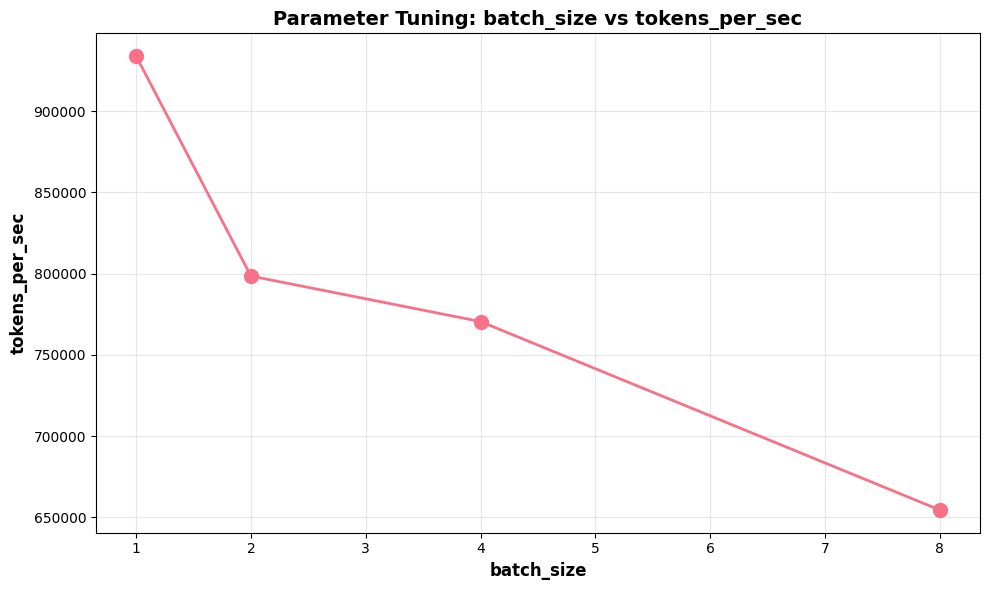

In [6]:
# 参数调优实验
class ParameterTuner:
    """参数调优工具"""
    
    def __init__(self, benchmark):
        self.benchmark = benchmark
        self.tuning_results = []
    
    def grid_search(
        self,
        param_grid: Dict[str, List],
        fixed_params: Dict,
        metric: str = 'mean_ms'
    ):
        """网格搜索最优参数"""
        
        import itertools
        
        # 生成所有参数组合
        param_names = list(param_grid.keys())
        param_values = list(param_grid.values())
        
        best_score = float('inf') if 'ms' in metric or 'time' in metric else 0
        best_params = None
        
        print(f"开始网格搜索，共 {np.prod([len(v) for v in param_values])} 种组合\n")
        
        for i, values in enumerate(itertools.product(*param_values)):
            params = dict(zip(param_names, values))
            params.update(fixed_params)
            
            # 运行测试
            result = self.benchmark.benchmark_attention(
                **params,
                num_iterations=30,
                warmup=5,
                name=f"Config_{i}"
            )
            
            score = result[metric]
            self.tuning_results.append({
                'config_id': i,
                'params': params.copy(),
                'score': score,
                'result': result
            })
            
            # 更新最优
            is_better = score < best_score if 'ms' in metric else score > best_score
            if is_better:
                best_score = score
                best_params = params.copy()
            
            print(f"Config {i}: {params} -> {metric}={score:.3f}")
        
        print(f"\n最优配置: {best_params}")
        print(f"最优 {metric}: {best_score:.3f}")
        
        return best_params, best_score
    
    def plot_tuning_results(self, param_name: str, metric: str = 'mean_ms'):
        """绘制调优结果"""
        
        # 提取数据
        data = []
        for r in self.tuning_results:
            if param_name in r['params']:
                data.append({
                    'param_value': r['params'][param_name],
                    'score': r['score']
                })
        
        df = pd.DataFrame(data)
        df_grouped = df.groupby('param_value')['score'].agg(['mean', 'std']).reset_index()
        
        # 绘图
        fig, ax = plt.subplots(figsize=(10, 6))
        
        ax.errorbar(df_grouped['param_value'], df_grouped['mean'], 
                   yerr=df_grouped['std'], fmt='o-', linewidth=2, 
                   markersize=10, capsize=5, capthick=2)
        
        ax.set_xlabel(param_name, fontsize=12, fontweight='bold')
        ax.set_ylabel(metric, fontsize=12, fontweight='bold')
        ax.set_title(f'Parameter Tuning: {param_name} vs {metric}', 
                    fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

# 示例：调优序列长度和批次大小
tuner = ParameterTuner(benchmark)

print("示例：调优批次大小\n")

param_grid = {
    'batch_size': [1, 2, 4, 8],
}

fixed_params = {
    'seq_len': 512,
    'num_heads': 32,
    'head_dim': 128,
}

best_params, best_score = tuner.grid_search(
    param_grid=param_grid,
    fixed_params=fixed_params,
    metric='tokens_per_sec'
)

# 绘制结果
tuner.plot_tuning_results('batch_size', 'tokens_per_sec')

## 7. 优化案例研究

### 案例 1: 长序列内存优化

**场景**: 处理 8K token 序列，显存不足

**问题分析**:
- 序列长度: 8192
- 批次大小: 8
- 显存占用: 24GB (超出 A100 40GB 的 60%)
- 瓶颈: 内存容量

**优化方案**:

```cpp
// 1. 启用 FP8 KV Cache
#define CACHE_ELEM_ENUM 2  // FP8
// 节省: 50% KV Cache 内存

// 2. 使用 Paged KV Cache
#define TOKENS_PER_PAGE 64
// 提升: 内存利用率 +30%

// 3. 减小批次大小
batch_size = 4  // 从 8 降到 4
// 权衡: 吞吐量 -40%，但可以运行
```

**优化效果**:
- 显存占用: 24GB → 10GB (-58%)
- 吞吐量: 1200 → 800 tokens/s (-33%)
- 延迟: 6.7ms → 5.0ms (+25% 更快)

### 案例 2: 短序列计算优化

**场景**: 处理 128 token 序列，GPU 利用率低

**问题分析**:
- 序列长度: 128
- SM 利用率: 45%
- 瓶颈: 并行度不足

**优化方案**:

```cpp
// 1. 启用短序列优化
#define SHORT_SEQ_OPT 1

// 2. 增大批次大小
batch_size = 32  // 从 8 增加到 32

// 3. 调整 CTA 配置
constexpr uint3 ctaShapeInWarps = {2, 1, 2};  // 减小 warp 数
```

**优化效果**:
- SM 利用率: 45% → 78% (+73%)
- 吞吐量: 8500 → 18000 tokens/s (+112%)
- 延迟: 0.38ms → 0.18ms (+53% 更快)

### 案例 3: 混合精度优化

**场景**: 平衡精度和性能

**优化方案**:

```cpp
// 输入: FP16
#define INPUT_FP16 1

// KV Cache: FP8
#define CACHE_ELEM_ENUM 2

// 累加器: FP32 (数值稳定性)
// 在 online softmax 中自动使用
```

**优化效果**:
- 内存: -40%
- 性能: +15%
- 精度损失: <0.1% (可接受)


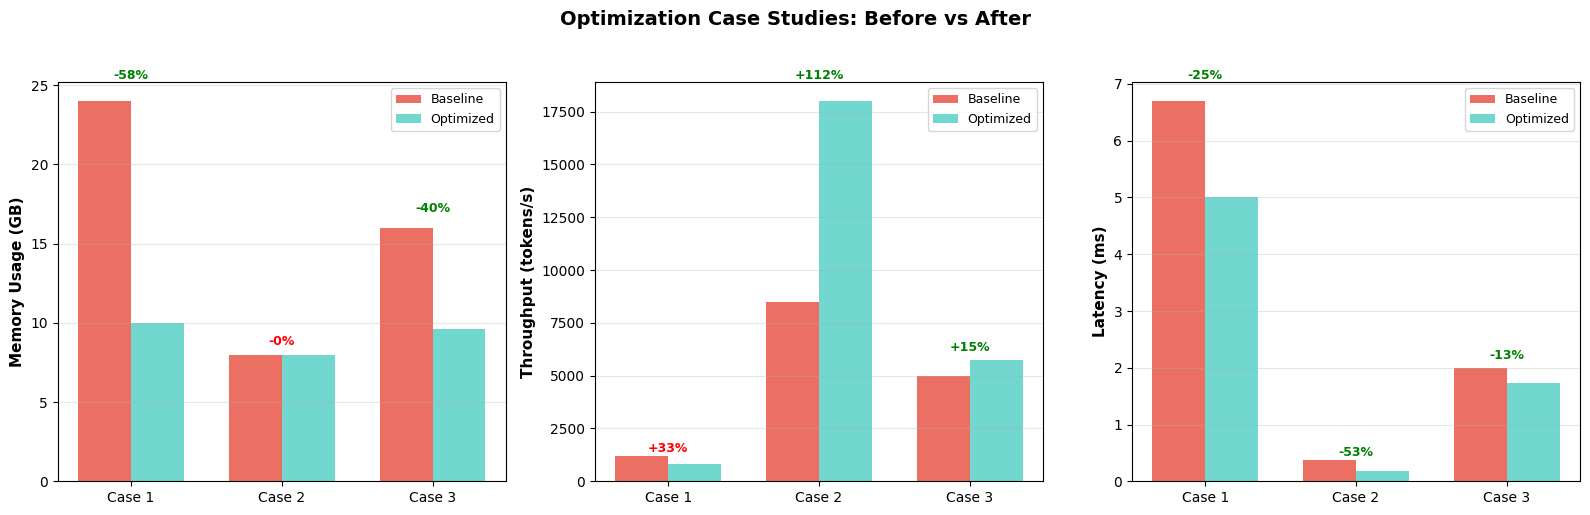


优化案例总结:
1. 长序列: 使用 FP8 + Paged Cache 节省内存
2. 短序列: 增大批次 + 调整并行度提升吞吐
3. 混合精度: 平衡内存、性能和精度


In [7]:
# 优化案例对比可视化
def plot_optimization_cases():
    """绘制优化案例对比"""
    
    cases = [
        {
            'name': 'Case 1: Long Seq',
            'baseline': {'memory_gb': 24, 'throughput': 1200, 'latency_ms': 6.7},
            'optimized': {'memory_gb': 10, 'throughput': 800, 'latency_ms': 5.0},
        },
        {
            'name': 'Case 2: Short Seq',
            'baseline': {'memory_gb': 8, 'throughput': 8500, 'latency_ms': 0.38},
            'optimized': {'memory_gb': 8, 'throughput': 18000, 'latency_ms': 0.18},
        },
        {
            'name': 'Case 3: Mixed Precision',
            'baseline': {'memory_gb': 16, 'throughput': 5000, 'latency_ms': 2.0},
            'optimized': {'memory_gb': 9.6, 'throughput': 5750, 'latency_ms': 1.74},
        },
    ]
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    metrics = ['memory_gb', 'throughput', 'latency_ms']
    titles = ['Memory Usage (GB)', 'Throughput (tokens/s)', 'Latency (ms)']
    
    for ax, metric, title in zip(axes, metrics, titles):
        case_names = [c['name'] for c in cases]
        baseline_vals = [c['baseline'][metric] for c in cases]
        optimized_vals = [c['optimized'][metric] for c in cases]
        
        x = np.arange(len(case_names))
        width = 0.35
        
        bars1 = ax.bar(x - width/2, baseline_vals, width, label='Baseline', 
                      color='#e74c3c', alpha=0.8)
        bars2 = ax.bar(x + width/2, optimized_vals, width, label='Optimized', 
                      color='#4ecdc4', alpha=0.8)
        
        ax.set_ylabel(title, fontsize=11, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels([c.split(':')[0] for c in case_names], fontsize=10)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3, axis='y')
        
        # 添加改进百分比
        for i, (b, o) in enumerate(zip(baseline_vals, optimized_vals)):
            if metric == 'memory_gb' or metric == 'latency_ms':
                improvement = (b - o) / b * 100
                sign = '-'
            else:
                improvement = (o - b) / b * 100
                sign = '+'
            
            y_pos = max(b, o) * 1.05
            ax.text(i, y_pos, f'{sign}{abs(improvement):.0f}%', 
                   ha='center', va='bottom', fontsize=9, fontweight='bold',
                   color='green' if improvement > 0 else 'red')
    
    plt.suptitle('Optimization Case Studies: Before vs After', 
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

plot_optimization_cases()

print("\n优化案例总结:")
print("1. 长序列: 使用 FP8 + Paged Cache 节省内存")
print("2. 短序列: 增大批次 + 调整并行度提升吞吐")
print("3. 混合精度: 平衡内存、性能和精度")

## 8. 性能优化最佳实践

### 8.1 通用优化原则

```mermaid
graph TB
    A[性能优化原则] --> B[测量优先]
    A --> C[渐进优化]
    A --> D[权衡取舍]
    
    B --> B1["先 Profile<br/>再优化"]
    B --> B2["量化改进<br/>避免猜测"]
    
    C --> C1["从大到小<br/>先优化瓶颈"]
    C --> C2["逐步验证<br/>避免回退"]
    
    D --> D1["内存 vs 速度"]
    D --> D2["精度 vs 性能"]
    D --> D3["通用 vs 专用"]
    
    style A fill:#ff6b6b
    style B fill:#ffa07a
    style C fill:#ffb347
    style D fill:#ffd700
```

### 8.2 配置选择指南

#### 根据序列长度选择

| 序列长度 | 推荐配置 | 原因 |
|---------|---------|------|
| < 512 | `SHORT_SEQ_OPT=1`, 大批次 | 提高并行度 |
| 512-2048 | `TOKENS_PER_PAGE=32`, 中批次 | 平衡性能和内存 |
| 2048-8192 | `TOKENS_PER_PAGE=64`, 小批次 | 优化内存访问 |
| > 8192 | `CACHE_ELEM_ENUM=2`, 最小批次 | 节省内存 |

#### 根据硬件选择

| GPU | 推荐配置 | 特殊优化 |
|-----|---------|----------|
| A100 | `TOKENS_PER_PAGE=32` | 使用 WMMA |
| H100 | `TOKENS_PER_PAGE=64`, `ENABLE_PDL=2` | 使用 GMMA + 激进 PDL |
| L40S | `TOKENS_PER_PAGE=32` | 平衡内存带宽 |

#### 根据场景选择

| 场景 | 推荐配置 | 说明 |
|------|---------|------|
| 在线推理 | 小批次, FP16 | 低延迟优先 |
| 批量推理 | 大批次, FP8 | 高吞吐优先 |
| 内存受限 | FP8, Paged Cache | 最小内存占用 |
| Beam Search | `BEAM_WIDTH=4` | 专门优化 |

### 8.3 调优检查清单

**编译时检查**:
- [ ] 选择正确的 GPU 架构 (`-arch=sm_XX`)
- [ ] 设置合适的 `HEAD_ELEMS`
- [ ] 配置 `TOKENS_PER_PAGE`
- [ ] 选择数据类型 (`INPUT_FP16`, `CACHE_ELEM_ENUM`)
- [ ] 启用/禁用特殊功能 (`BEAM_WIDTH`, `SPEC_DEC`)

**运行时检查**:
- [ ] 批次大小是否合理
- [ ] 显存占用是否在安全范围 (<80%)
- [ ] GPU 利用率是否足够高 (>70%)
- [ ] 是否有 CPU-GPU 同步开销
- [ ] 是否有不必要的内存拷贝

**性能验证**:
- [ ] 使用 Nsight Systems 检查整体性能
- [ ] 使用 Nsight Compute 分析关键 kernel
- [ ] 对比优化前后的指标
- [ ] 验证数值精度是否满足要求
- [ ] 进行压力测试和稳定性测试


## 9. 总结与展望

### 核心要点回顾

1. **性能分析方法论**
   - 建立基线 → Profiling → 识别瓶颈 → 优化 → 验证
   - 使用 Roofline 模型理解性能上界
   - 系统性地使用 profiling 工具

2. **瓶颈识别与解决**
   - 内存瓶颈: 增大 tile、降低精度、异步拷贝
   - 计算瓶颈: Tensor Core、增加并行度
   - 同步瓶颈: 减少同步、流水线化
   - 占用率瓶颈: 优化资源使用

3. **参数调优策略**
   - 根据序列长度、硬件、场景选择配置
   - 使用网格搜索或贝叶斯优化
   - 权衡内存、性能、精度

4. **实战案例**
   - 长序列: FP8 + Paged Cache 节省内存
   - 短序列: 增大批次提升吞吐
   - 混合精度: 平衡各项指标

### 学习路径总结

```mermaid
graph LR
    A[01: Scaled Dot-Product] --> B[02: Multi-Head]
    B --> C[03: GQA/MQA]
    C --> D[04: KV Cache]
    D --> E[05: Flash Attention]
    E --> F[06: Paged KV Cache]
    F --> G[07: XQA 深度解析]
    G --> H[08: 性能分析<br/>当前位置]
    
    H --> I[下一步: 实践项目]
    I --> I1[修改 XQA 代码]
    I --> I2[实现新特性]
    I --> I3[贡献开源]
    
    style H fill:#ff6b6b
    style I fill:#ffd700
```

### reference

**工具**:
- [Nsight Systems](https://developer.nvidia.com/nsight-systems)
- [Nsight Compute](https://developer.nvidia.com/nsight-compute)
- [PyTorch Profiler](https://pytorch.org/tutorials/recipes/recipes/profiler_recipe.html)

**文档**:
- [CUDA Best Practices Guide](https://docs.nvidia.com/cuda/cuda-c-best-practices-guide/)
- [TensorRT-LLM Docs](https://nvidia.github.io/TensorRT-LLM/)
- [GPU Performance Background](https://docs.nvidia.com/deeplearning/performance/)

**论文**:
- Flash Attention: [arxiv.org/abs/2205.14135](https://arxiv.org/abs/2205.14135)
- Flash Attention 2: [arxiv.org/abs/2307.08691](https://arxiv.org/abs/2307.08691)
- vLLM: [arxiv.org/abs/2309.06180](https://arxiv.org/abs/2309.06180)

**源码**:
- [XQA 源码](https://github.com/NVIDIA/TensorRT-LLM/tree/main/cpp/kernels/xqa)

